# 1 - EXPLORAÇÃO INICIAL

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
url = 'https://raw.githubusercontent.com/alvaroriz/datascience_datasets/refs/heads/main/spotfy_churn.csv'
base = pd.read_csv(url)
base.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [3]:
base.shape

(8000, 12)

In [4]:
base.columns

Index(['user_id', 'gender', 'age', 'country', 'subscription_type',
       'listening_time', 'songs_played_per_day', 'skip_rate', 'device_type',
       'ads_listened_per_week', 'offline_listening', 'is_churned'],
      dtype='object')

In [5]:
# Verificando o tipo de cada variável
base.dtypes

,0
user_id,int64
gender,object
age,int64
country,object
subscription_type,object
listening_time,int64
songs_played_per_day,int64
skip_rate,float64
device_type,object
ads_listened_per_week,int64


In [6]:
# Verificar se há duplicatas
base.duplicated().sum()

0

In [7]:
# Verificar valores ausentes
base.isnull().sum()

,0
user_id,0
gender,0
age,0
country,0
subscription_type,0
listening_time,0
songs_played_per_day,0
skip_rate,0
device_type,0
ads_listened_per_week,0


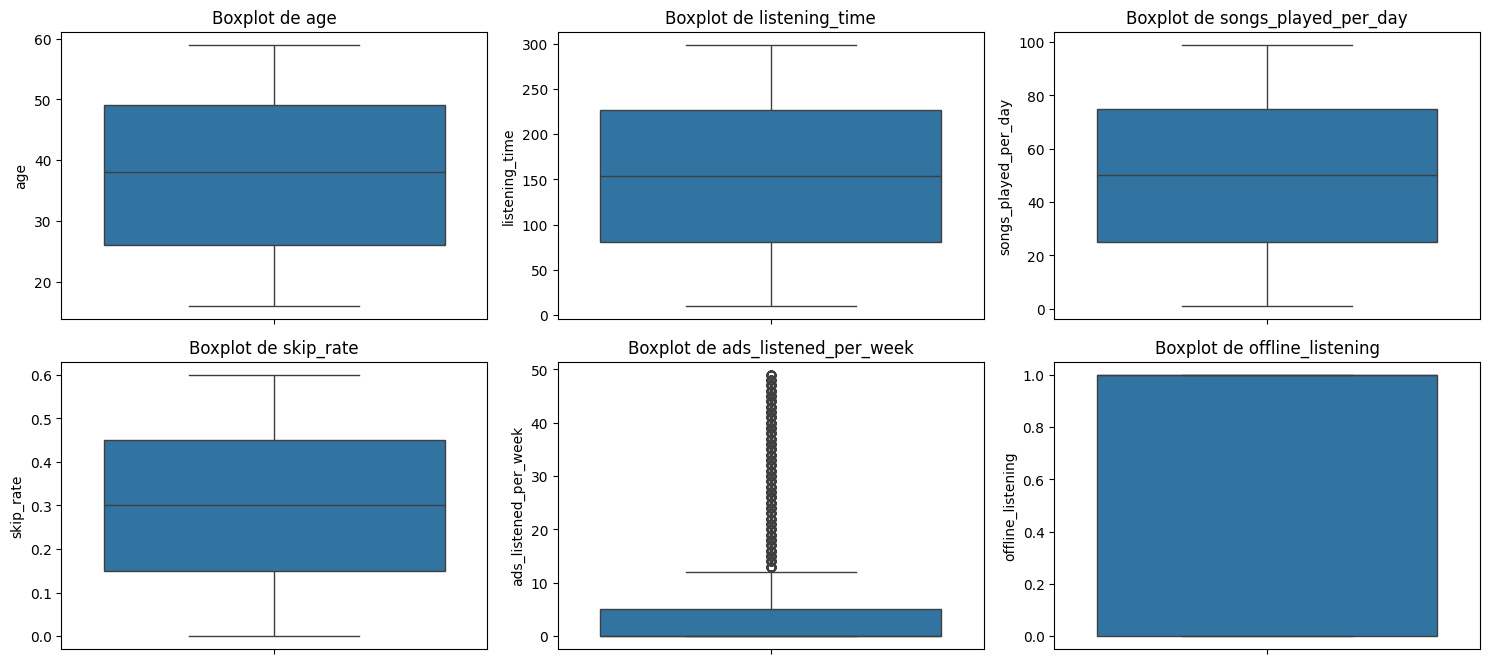

In [8]:
# Outliers
lista = []
for i in base.columns:
  if base.dtypes[i] == 'int64' or base.dtypes[i] == 'float64':
    if i == 'user_id' or i == 'is_churned':
      pass
    else:
      lista.append(i)
# Configurar o layout dos subplots
fig, axes = plt.subplots(nrows=len(lista)//3 + 1, ncols=3, figsize=(15, 10))
axes = axes.flatten()  # Achatar o array de eixos para facilitar a iteração

# Criar um boxplot para cada variável
for idx, coluna in enumerate(lista):
    if idx < len(axes):
        sns.boxplot(y=base[coluna], ax=axes[idx])
        axes[idx].set_title(f'Boxplot de {coluna}')
        axes[idx].set_xlabel('')

# Remover eixos vazios se houver
for idx in range(len(lista), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [9]:
# offline listening é uma variável binária
base['offline_listening'].value_counts()

,count
offline_listening,
1,5982
0,2018


In [10]:
# Estatísticas descritivas para identificar outliers
for coluna in lista:
    Q1 = base[coluna].quantile(0.25)
    Q3 = base[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = base[(base[coluna] < limite_inferior) | (base[coluna] > limite_superior)]
    print(f"{coluna}: {len(outliers)} outliers")

age: 0 outliers
listening_time: 0 outliers
songs_played_per_day: 0 outliers
skip_rate: 0 outliers
ads_listened_per_week: 1683 outliers
offline_listening: 0 outliers


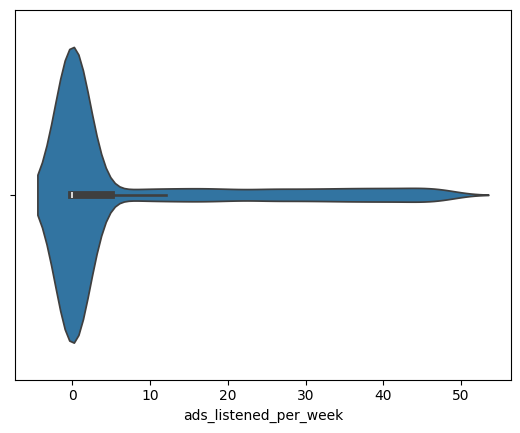

In [11]:
# Investigando melhor a variável ads_listened_per_week
# violin plot
sns.violinplot(x=base['ads_listened_per_week'])
plt.show()

In [12]:
base['ads_listened_per_week'].describe()

,ads_listened_per_week
count,8000.000000
mean,6.943875
std,13.617953
min,0.000000
25%,0.000000
50%,0.000000
75%,5.000000
max,49.000000


In [13]:
(base['ads_listened_per_week'] > 12.5).value_counts()

,count
ads_listened_per_week,
False,6317
True,1683


In [14]:
investigacao = base[base['ads_listened_per_week'] >= 12.5]
investigacao['subscription_type'].value_counts()

,count
subscription_type,
Free,1683


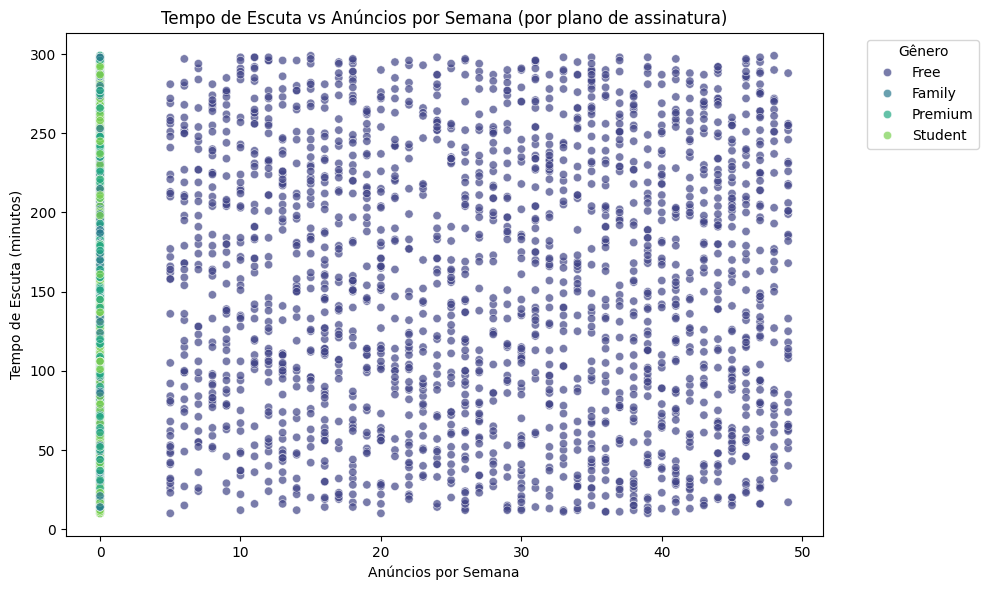

In [15]:
# correlação entre ads_listened_per_week e listening_time
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=base['ads_listened_per_week'],
    y=base['listening_time'],
    hue=base['subscription_type'],
    palette='viridis',
    alpha=0.7
)
plt.title('Tempo de Escuta vs Anúncios por Semana (por plano de assinatura)')
plt.xlabel('Anúncios por Semana')
plt.ylabel('Tempo de Escuta (minutos)')
plt.legend(title='Gênero', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

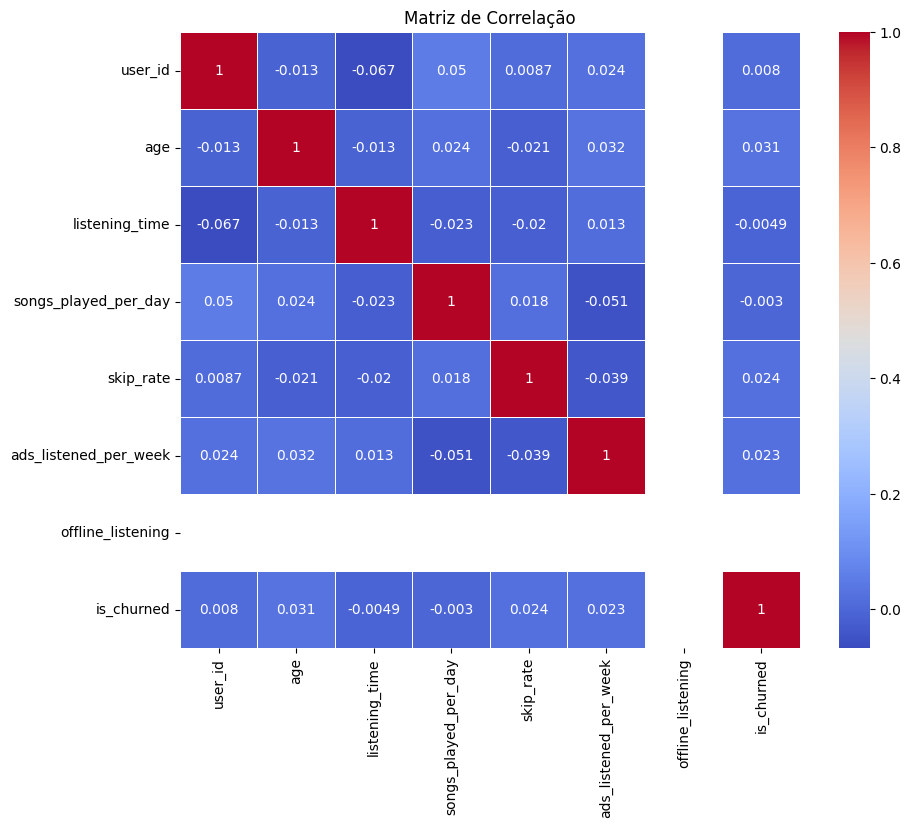

In [16]:
# matriz de correlação
numeric_investigacao = investigacao.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_investigacao.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlação')
plt.show()

# 2 - PRÉ-PROCESSAMENTO

In [17]:
# Dividindo em base de trabalho e base de validaçao
validacao = base.sample(frac=0.2, random_state=42)
base = base.drop(validacao.index)
print(f'Base de trabalho: {base.shape}')
print(f'Base de validação: {validacao.shape}')

Base de trabalho: (6400, 12)
Base de validação: (1600, 12)


In [18]:
# Divisão da base de trabalho em treino e teste
base_train, base_test = train_test_split(base, test_size=0.2, random_state=42)
X_train = base_train.drop('is_churned', axis=1)
y_train = base_train['is_churned']

In [19]:
base_train.shape, base_test.shape

((5120, 12), (1280, 12))

In [20]:
X_train.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening
2350,2351,Male,24,PK,Student,199,90,0.55,Web,0,1
4051,4052,Female,21,AU,Family,110,81,0.34,Mobile,0,1
6471,6472,Female,42,FR,Free,122,17,0.40,Web,24,0
3330,3331,Male,42,US,Free,204,32,0.05,Web,36,0
7101,7102,Female,40,US,Family,97,97,0.23,Web,0,1


In [21]:
# verificar cardinalidade das variáveis categóricas
for coluna in X_train.columns:
  if X_train.dtypes[coluna] == 'object':
    print(f'{coluna}: {X_train[coluna].nunique()}')

gender: 3
country: 8
subscription_type: 4
device_type: 3


In [22]:
X_train['subscription_type'].value_counts()

,count
subscription_type,
Premium,1374
Free,1269
Student,1241
Family,1236


In [23]:
# Ordinal enconding em subscription_type
subscription_mapping = {'Free': 0, 'Student': 1, 'Family': 2,'Premium':3}
X_train['subscription_type'] = X_train['subscription_type'].map(subscription_mapping)
X_train['subscription_type'].value_counts()

,count
subscription_type,
3,1374
0,1269
1,1241
2,1236


In [24]:
# One hot enconding com k -1 para gender e device_type
X_train = pd.get_dummies(X_train, columns=['gender', 'device_type'],drop_first=True)
X_train.head()

,user_id,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,gender_Male,gender_Other,device_type_Mobile,device_type_Web
2350,2351,24,PK,1,199,90,0.55,0,1,True,False,False,True
4051,4052,21,AU,2,110,81,0.34,0,1,False,False,True,False
6471,6472,42,FR,0,122,17,0.40,24,0,False,False,False,True
3330,3331,42,US,0,204,32,0.05,36,0,True,False,False,True
7101,7102,40,US,2,97,97,0.23,0,1,False,False,False,True


In [25]:
# Label enconding em Country
label_encoder = LabelEncoder()
X_train['country'] = label_encoder.fit_transform(X_train['country'])
X_train['country'].value_counts()

,count
country,
2,668
5,660
0,659
4,647
7,639
1,630
6,613
3,604


In [26]:
X_train.shape

(5120, 13)

<function matplotlib.pyplot.show(close=None, block=None)>

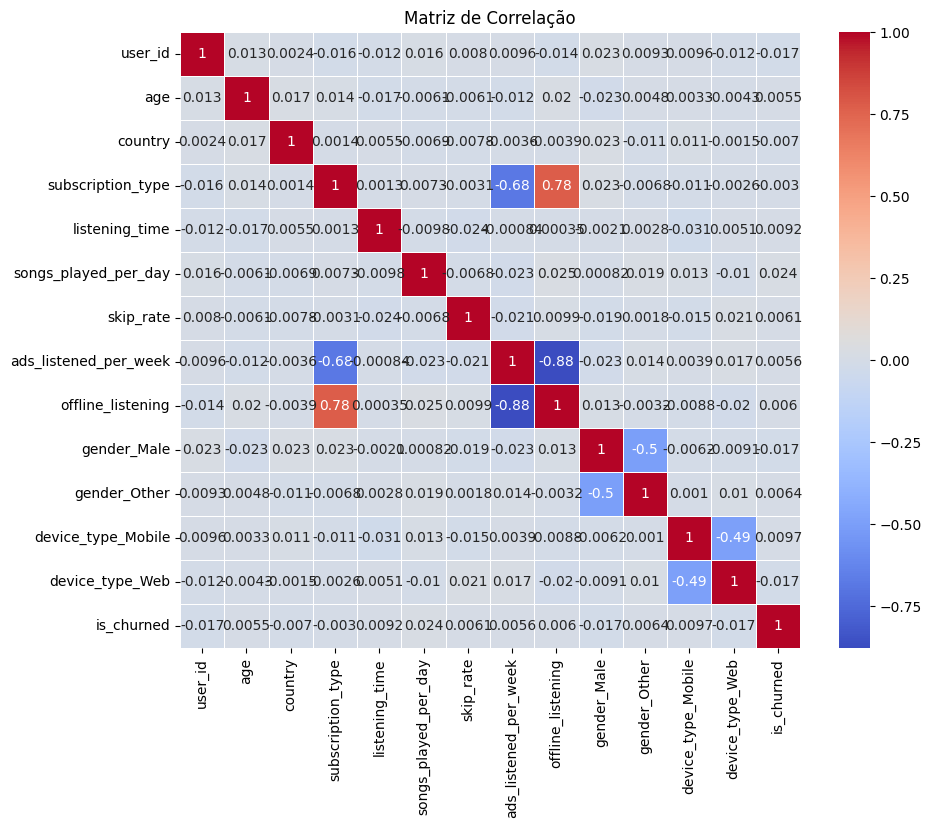

In [27]:
# Matriz correlação
tudo = pd.concat([X_train, y_train], axis=1)
corr_matrix = tudo.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlação')
plt.show

In [28]:
# ads_listened_per_week|offline_listening = -0.88
# ads_listened_per_week|subscription_type = -0.68
# offline_listening|subscription_type = 0.78

In [29]:
# Converter booleanos para inteiros (como você já fez)
X_train_vif = X_train.copy()
for col in X_train_vif.columns:
    if X_train_vif[col].dtype == 'bool':
        X_train_vif[col] = X_train_vif[col].astype(int)

# Calcular VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_vif.values, i)
                   for i in range(X_train_vif.shape[1])]

# Ordenar por VIF para melhor visualização
vif_data = vif_data.sort_values("VIF", ascending=False)
vif_data

,feature,VIF
8,offline_listening,16.426980
1,age,8.048505
3,subscription_type,7.118561
4,listening_time,4.037927
5,songs_played_per_day,3.889546
0,user_id,3.872732
6,skip_rate,3.753677
7,ads_listened_per_week,3.449820
2,country,3.153237
9,gender_Male,1.952398


In [30]:
# excluir offline_listening, subscription_type
X_train = X_train.drop(['offline_listening', 'subscription_type','user_id'], axis=1)
X_train.head()

,age,country,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,gender_Male,gender_Other,device_type_Mobile,device_type_Web
2350,24,5,199,90,0.55,0,True,False,False,True
4051,21,0,110,81,0.34,0,False,False,True,False
6471,42,3,122,17,0.40,24,False,False,False,True
3330,42,7,204,32,0.05,36,True,False,False,True
7101,40,7,97,97,0.23,0,False,False,False,True


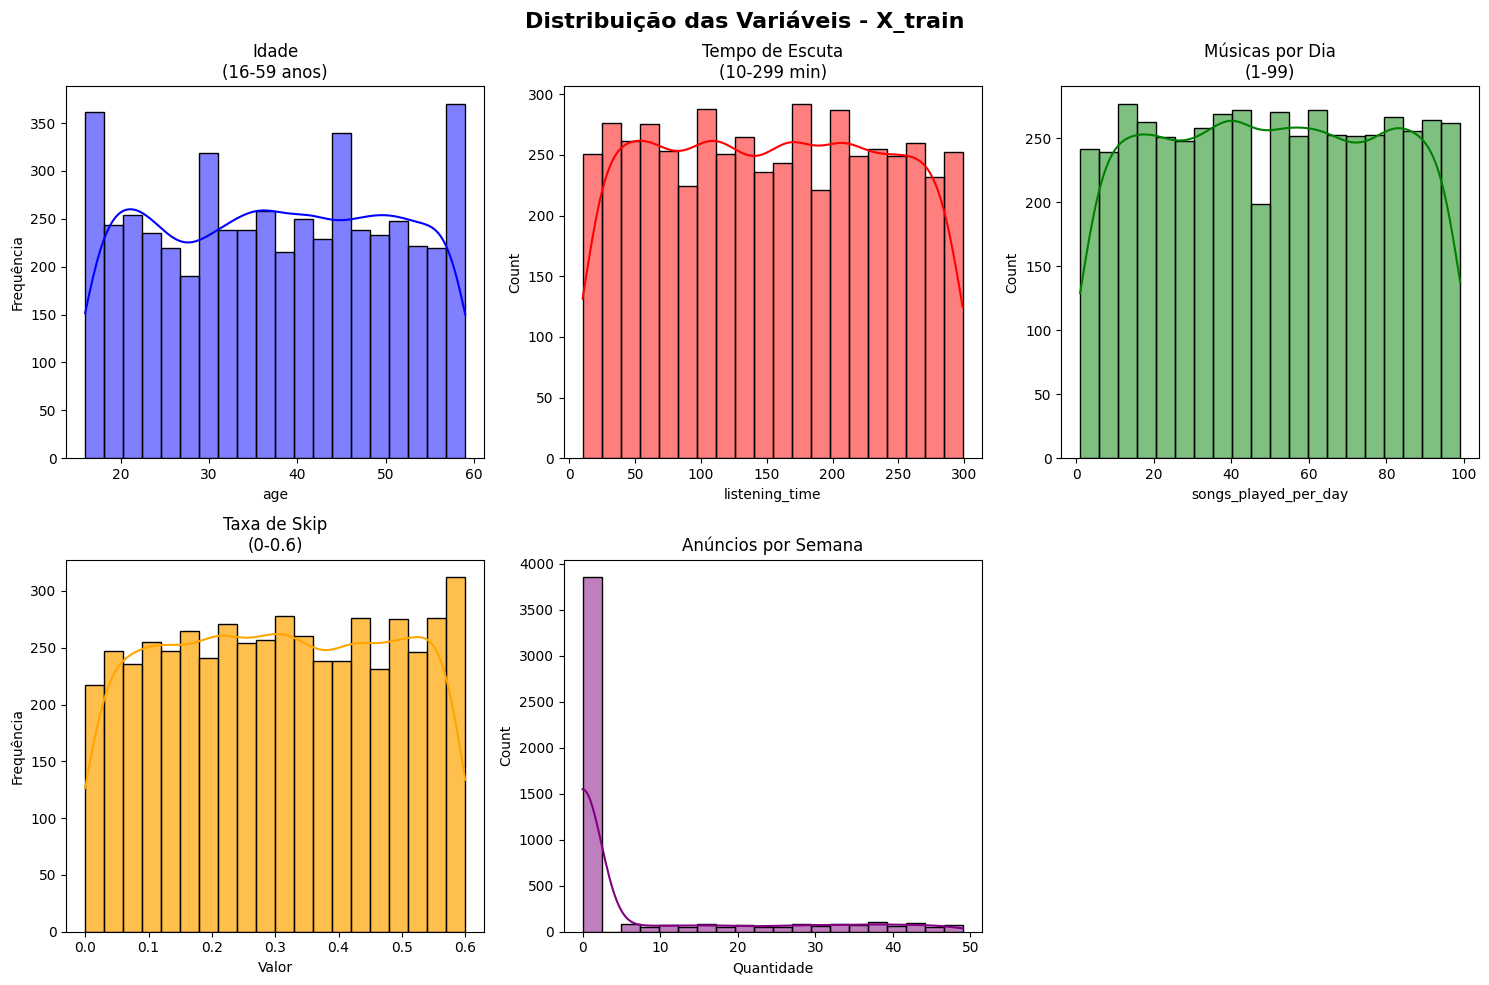

In [31]:
# Criando subplots lado a lado
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribuição das Variáveis - X_train', fontsize=16, fontweight='bold')

# Plotando cada variável em seu próprio subplot com KDE
sns.histplot(ax=axes[0,0], data=X_train, x='age', bins=20, kde=True, color='blue', edgecolor='black')
axes[0,0].set_title('Idade\n(16-59 anos)')
axes[0,0].set_ylabel('Frequência')

sns.histplot(ax=axes[0,1], data=X_train, x='listening_time', bins=20, kde=True, color='red', edgecolor='black')
axes[0,1].set_title('Tempo de Escuta\n(10-299 min)')

sns.histplot(ax=axes[0,2], data=X_train, x='songs_played_per_day', bins=20, kde=True, color='green', edgecolor='black')
axes[0,2].set_title('Músicas por Dia\n(1-99)')

sns.histplot(ax=axes[1,0], data=X_train, x='skip_rate', bins=20, kde=True, alpha=0.7, color='orange', edgecolor='black')
axes[1,0].set_title('Taxa de Skip\n(0-0.6)')
axes[1,0].set_ylabel('Frequência')
axes[1,0].set_xlabel('Valor')

# Adicionando a nova variável ads_listened_per_week
sns.histplot(ax=axes[1,1], data=X_train, x='ads_listened_per_week', bins=20, kde=True, color='purple', edgecolor='black')
axes[1,1].set_title('Anúncios por Semana')
axes[1,1].set_xlabel('Quantidade')

# Remover o subplot vazio (agora é o [1,2])
fig.delaxes(axes[1,2])

plt.tight_layout()
plt.show()

In [32]:
X_train['ads_listened_per_week'].describe()

,ads_listened_per_week
count,5120.000000
mean,6.771680
std,13.438057
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,49.000000


In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Pré-processador para treino
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['age', 'listening_time', 'songs_played_per_day', 'skip_rate', 'ads_listened_per_week']),
    ],
    remainder='passthrough'
)

# Aplicar FIT_TRANSFORM apenas no treino
X_train_processed = pd.DataFrame(
    preprocessor.fit_transform(X_train),
    columns=preprocessor.get_feature_names_out(),
    index=X_train.index
)
X_train = X_train_processed
X_train.head()

,num__age,num__listening_time,num__songs_played_per_day,num__skip_rate,num__ads_listened_per_week,remainder__country,remainder__gender_Male,remainder__gender_Other,remainder__device_type_Mobile,remainder__device_type_Web
2350,-1.060281,0.548165,1.398714,1.427057,-0.503967,5,True,False,False,True
4051,-1.29526,-0.519017,1.081993,0.216374,-0.503967,0,False,False,True,False
6471,0.349592,-0.375127,-1.170246,0.562283,1.28218,3,False,False,False,True
3330,0.349592,0.608119,-0.642377,-1.455522,2.175253,7,True,False,False,True
7101,0.19294,-0.674897,1.645052,-0.417794,-0.503967,7,False,False,False,True


In [34]:
X_train['num__ads_listened_per_week'].describe()

,num__ads_listened_per_week
count,5120.000000
unique,46.000000
top,-0.503967
freq,3851.000000


/tmp/ipython-input-35-2894349383.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='is_churned', data=base_train, palette='viridis')


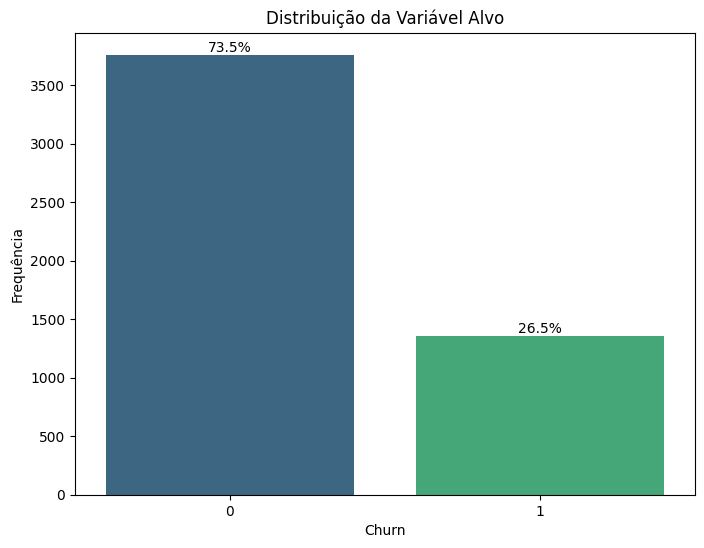

In [35]:
# grafico de barras com percentual para a variavel alvo
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='is_churned', data=base_train, palette='viridis')
plt.title('Distribuição da Variável Alvo')
plt.xlabel('Churn')
plt.ylabel('Frequência')

# Adicionar percentuais nas barras
total = len(base_train)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

In [36]:
# aplicando o smote
#from imblearn.over_sampling import SMOTE
#smote = SMOTE(random_state=42)
#X_treino_balanced, y_treino_balanced = smote.fit_resample(X_train, y_train)
#base_treino_final = pd.concat([
#    pd.DataFrame(X_treino_balanced),
#    pd.DataFrame(y_treino_balanced)
#], axis=1)
#base_treino_final['is_churned'].value_counts()
#------------------------------------------------------------------------------
# tentando undersampling
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_treino_balanced, y_treino_balanced = rus.fit_resample(X_train, y_train)
base_treino_final = pd.concat([
    pd.DataFrame(X_treino_balanced),
    pd.DataFrame(y_treino_balanced)
], axis=1)
base_treino_final['is_churned'].value_counts()

,count
is_churned,
0,1359
1,1359


In [37]:
base_treino_final.shape

(2718, 11)

# 3 - LINHA DE BASE (logistic regression)

In [38]:
# Pré-processamento do teste
X_test = base_test.drop('is_churned', axis=1)
y_test = base_test['is_churned']
X_test = X_test.drop(['offline_listening', 'subscription_type', 'user_id'], axis=1)
X_test = pd.get_dummies(X_test, columns=['gender', 'device_type'], drop_first=True)
X_test['country'] = label_encoder.transform(X_test['country'])  # Use transform, não fit_transform
# Aplicar apenas TRANSFORM no teste (usando o preprocessor já treinado)
X_test_processed = pd.DataFrame(
    preprocessor.transform(X_test),  # Apenas transform, não fit_transform
    columns=preprocessor.get_feature_names_out(),
    index=X_test.index
)
X_test = X_test_processed
X_test.head()

,num__age,num__listening_time,num__songs_played_per_day,num__skip_rate,num__ads_listened_per_week,remainder__country,remainder__gender_Male,remainder__gender_Other,remainder__device_type_Mobile,remainder__device_type_Web
2511,-0.981954,0.692055,1.715435,-1.340219,-0.503967,7,True,False,True,False
3495,1.054529,-0.782815,1.469096,1.715315,-0.503967,5,False,True,True,False
5208,-0.825302,-1.706107,-0.008935,0.10107,1.951985,2,True,False,True,False
6894,0.506245,-1.034622,1.046802,-1.340219,2.10083,5,True,False,False,False
166,-1.138607,-0.698879,-0.677569,0.389328,-0.503967,3,True,False,False,True


In [39]:
# criando um modelo de benchmark de LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,classification_report
# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_treino_balanced, y_treino_balanced)

# Make predictions on the test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("\n" + "="*50 + "\n")
print(f"Acurácia do modelo: {accuracy:.4f}")
print("\n" + "="*50)
print(classification_report(y_test,y_pred))



Acurácia do modelo: 0.5086

              precision    recall  f1-score   support

           0       0.77      0.51      0.61       968
           1       0.25      0.52      0.34       312

    accuracy                           0.51      1280
   macro avg       0.51      0.51      0.47      1280
weighted avg       0.64      0.51      0.54      1280



# 4 - PYCARET

In [40]:
!pip install pycaret

  Using cached scipy-1.11.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached scipy-1.11.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (36.4 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mizani 0.13.5 requires pandas>=2.2.0, but you have pandas 2.1.4 which is incompatible.
plotnine 0.14.6 requires matplotlib>=3.8.0, but you have matplotlib 3.7.5 which is incompatible.
plotnine 0.14.6 requires pandas>=2.2.0, but you have pandas 2.1.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.11.4 which is incompatible.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.4.2 which is incompatible.


In [41]:
# usando pycaret
from pycaret.classification import *

In [42]:
experimento = setup(data=base_treino_final, target='is_churned', session_id=42)

,Description,Value
0,Session id,42
1,Target,is_churned
2,Target type,Binary
3,Original data shape,"(2718, 11)"
4,Transformed data shape,"(2718, 18)"
5,Transformed train set shape,"(1902, 18)"
6,Transformed test set shape,"(816, 18)"
7,Categorical features,10
8,Preprocess,True
9,Imputation type,simple


In [43]:
modelos = compare_models(sort = 'Accuracy', fold = 10)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.5199,0.5197,0.5372,0.5171,0.5255,0.0398,0.0404,0.2260
et,Extra Trees Classifier,0.5115,0.5103,0.5014,0.5108,0.5057,0.0230,0.0231,0.4000
ridge,Ridge Classifier,0.5063,0.5034,0.5237,0.5053,0.5141,0.0126,0.0128,0.0900
ada,Ada Boost Classifier,0.5063,0.5032,0.5079,0.5059,0.5062,0.0126,0.0125,0.2170
lda,Linear Discriminant Analysis,0.5058,0.5033,0.5227,0.5048,0.5133,0.0116,0.0117,0.0930
lr,Logistic Regression,0.5053,0.5033,0.5216,0.5044,0.5126,0.0105,0.0106,1.9640
nb,Naive Bayes,0.5042,0.5004,0.4901,0.5052,0.4969,0.0085,0.0086,0.1790
qda,Quadratic Discriminant Analysis,0.5036,0.5127,0.4456,0.5102,0.4578,0.0072,0.0101,0.0980
rf,Random Forest Classifier,0.5005,0.4999,0.5099,0.4988,0.5039,0.0010,0.0011,0.4320
dummy,Dummy Classifier,0.4995,0.5000,0.1000,0.0497,0.0664,0.0000,0.0000,0.0900


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [44]:
modelo = create_model('et')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5707,0.5792,0.6354,0.5648,0.5980,0.1408,0.1419
1,0.5236,0.5181,0.5158,0.5213,0.5185,0.0470,0.0470
2,0.5000,0.5186,0.4842,0.5000,0.4920,0.0000,0.0000
3,0.5000,0.5030,0.5053,0.5000,0.5026,0.0000,0.0000
4,0.5000,0.4961,0.4632,0.5000,0.4809,0.0000,0.0000
5,0.4789,0.4974,0.4632,0.4783,0.4706,-0.0421,-0.0421
6,0.5053,0.5032,0.4737,0.5056,0.4891,0.0105,0.0105
7,0.5158,0.5138,0.4842,0.5169,0.5000,0.0316,0.0316
8,0.4737,0.4299,0.4526,0.4725,0.4624,-0.0526,-0.0527


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [45]:
print(modelo)

ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=42, verbose=0,
                     warm_start=False)


In [46]:
modelo_tunado = tune_model(modelo)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.4921,0.5285,0.5729,0.4955,0.5314,-0.0166,-0.0168
1,0.5288,0.5543,0.5789,0.5238,0.5500,0.0581,0.0584
2,0.5316,0.5385,0.4842,0.5349,0.5083,0.0632,0.0634
3,0.4895,0.4857,0.5158,0.4900,0.5026,-0.0211,-0.0211
4,0.5105,0.4974,0.4947,0.5109,0.5027,0.0211,0.0211
5,0.5000,0.5295,0.4947,0.5000,0.4974,0.0000,0.0000
6,0.5105,0.5026,0.5368,0.5100,0.5231,0.0211,0.0211
7,0.5158,0.4985,0.5579,0.5146,0.5354,0.0316,0.0317
8,0.4579,0.4376,0.4105,0.4535,0.4309,-0.0842,-0.0846


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [47]:
predict_model(modelo)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.4890,0.4915,0.4951,0.4891,0.4921,-0.0221,-0.0221


,num__age,num__listening_time,num__songs_played_per_day,num__skip_rate,num__ads_listened_per_week,remainder__country,remainder__gender_Male,remainder__gender_Other,remainder__device_type_Mobile,remainder__device_type_Web,is_churned,prediction_label,prediction_score
5069,0.349592,-0.914713,-1.240628,-0.706052,-0.503967,6,False,True,True,False,0,0,0.53
4377,0.976202,-0.171284,1.645052,-1.051961,-0.503967,0,True,False,True,False,0,1,0.71
1841,-0.042039,0.871917,-1.592540,-1.282567,-0.503967,7,False,True,False,False,1,1,0.65
4308,0.662897,-1.250456,0.835654,-0.590748,-0.503967,4,True,False,False,False,1,1,0.54
2206,0.271266,-0.279201,1.328331,1.196450,-0.503967,5,True,False,True,False,1,1,0.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4849,0.584571,-1.250456,1.609861,-0.936658,-0.503967,4,True,False,False,False,1,1,0.60
1364,0.897876,1.639328,-1.029481,1.311754,-0.503967,5,True,False,True,False,1,0,0.75
4035,-1.686891,-1.046612,-1.099863,-0.475445,-0.503967,6,True,False,True,False,1,0,0.56
6533,-1.060281,-1.214484,-1.029481,1.254102,-0.131853,2,True,False,True,False,0,0,0.56


In [48]:
base_teste = pd.concat([
    pd.DataFrame(X_test),
    pd.DataFrame(y_test)
], axis=1)
pred = predict_model(modelo, data=base_teste)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.4969,0.4813,0.4904,0.2398,0.3221,-0.0079,-0.0091


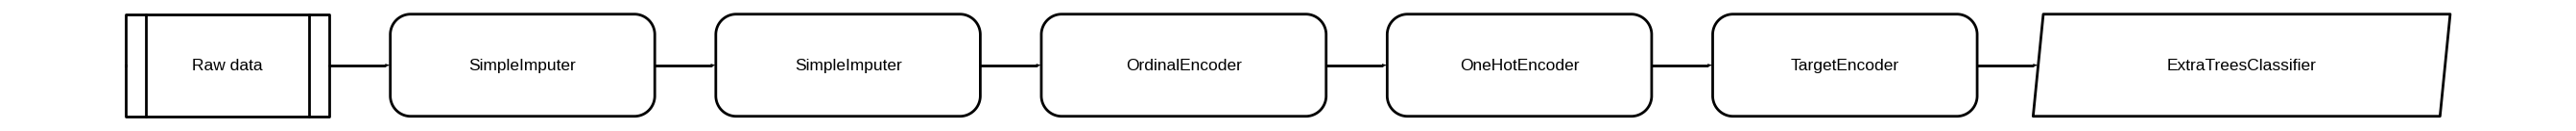

In [49]:
plot_model(modelo, plot = 'pipeline', )

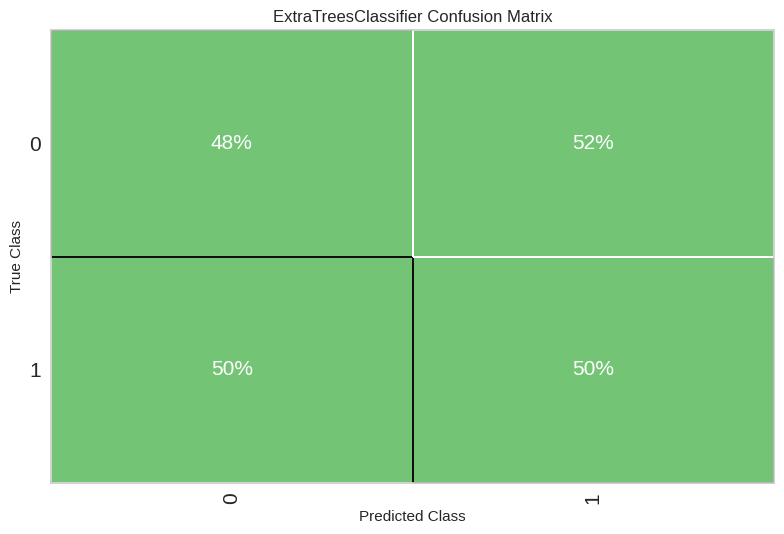

In [50]:
plot_model(modelo, plot = 'confusion_matrix', plot_kwargs={'percent': True})

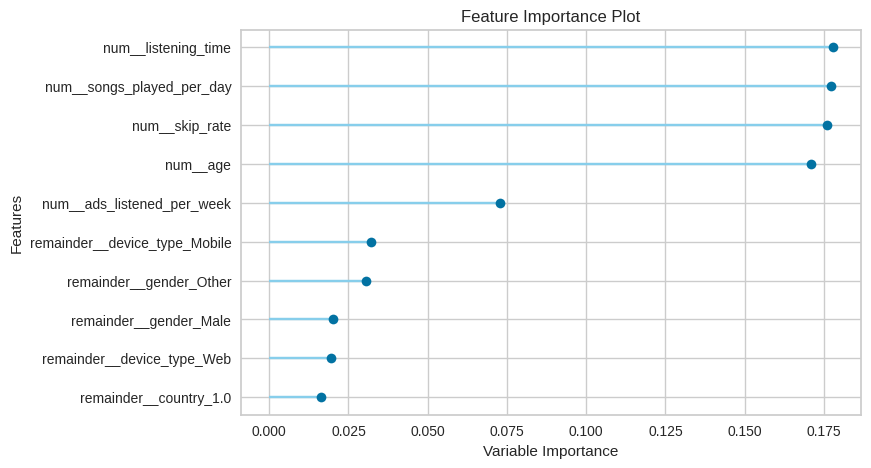

In [51]:
plot_model(modelo, plot = 'feature')

In [52]:
plot_model(modelo, plot = 'parameter')

,Parameters
bootstrap,False
ccp_alpha,0.0
class_weight,None
criterion,gini
max_depth,None
max_features,sqrt
max_leaf_nodes,None
max_samples,None
min_impurity_decrease,0.0
min_samples_leaf,1


# 5 - VALIDAÇÃO

In [53]:
validacao.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
2215,2216,Female,21,CA,Premium,184,22,0.40,Mobile,0,1,0
2582,2583,Other,23,US,Premium,234,10,0.38,Desktop,0,1,0
1662,1663,Other,55,US,Student,33,93,0.09,Mobile,0,1,0
3027,3028,Other,39,PK,Family,207,98,0.60,Mobile,0,1,1
4343,4344,Female,16,UK,Premium,117,56,0.00,Web,0,1,1


In [54]:
# Aplicando as transformações do treino na validação
X_validacao = validacao.drop('is_churned', axis=1)
y_validacao = validacao['is_churned']
X_validacao = X_validacao.drop(['offline_listening', 'subscription_type','user_id'], axis=1)
X_validacao = pd.get_dummies(X_validacao, columns=['gender', 'device_type'], drop_first=True)
X_validacao['country'] = label_encoder.transform(X_validacao['country'])  # Apenas transform, não fit_transform
# Aplicar apenas TRANSFORM na validação (usando o preprocessor já treinado)
X_validacao_processed = pd.DataFrame(
    preprocessor.transform(X_validacao),  # Apenas transform, não fit_transform
    columns=preprocessor.get_feature_names_out(),
    index=X_validacao.index
)
X_validacao = X_validacao_processed
X_validacao.head()

,num__age,num__listening_time,num__songs_played_per_day,num__skip_rate,num__ads_listened_per_week,remainder__country,remainder__gender_Male,remainder__gender_Other,remainder__device_type_Mobile,remainder__device_type_Web
2215,-1.29526,0.368303,-0.99429,0.562283,-0.503967,1,False,False,True,False
2582,-1.138607,0.967843,-1.416584,0.44698,-0.503967,7,False,True,False,False
1662,1.367834,-1.442309,1.504287,-1.224916,-0.503967,7,False,True,True,False
3027,0.114613,0.644091,1.680244,1.715315,-0.503967,5,False,True,True,False
4343,-1.686891,-0.435081,0.202212,-1.74378,-0.503967,6,False,False,False,True


In [55]:
validacao_transformada = pd.concat([
    pd.DataFrame(X_validacao),
    pd.DataFrame(y_validacao)
], axis=1)
pred_validacao = predict_model(modelo, data=validacao_transformada)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.5131,0.5224,0.5000,0.2567,0.3393,0.0133,0.0152
